### Fashion-MNIST Image Classification

This notebook demonstrates image classification on the Fashion-MNIST dataset using a feedforward neural network built with TensorFlow/Keras, including preprocessing, augmentation, training, and performance evaluation.

## Links
- Colab: https://colab.research.google.com/drive/1KmbCKc5Bho8JBcguEJV0_NpNCUNKHC4R?usp=sharing
- GitHub: https://github.com/alyssaiapalucci4/assignment-12-fashion-mnist-classification

## Name: Alyssa Iapalucci

In [ ]:
# Step 1: Data Loading

from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Check shapes
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training shape: (60000, 28, 28)
Test shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)


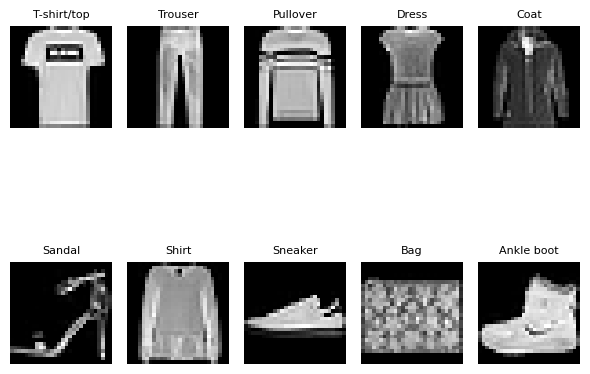

In [ ]:
# Step 2 — Visualize Sample Images

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(6,6))  # smaller figure = less blur effect

for i in range(10):
    index = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[index], cmap='gray', vmin=0, vmax=255)
    plt.title(class_names[i], fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Image Preprocessing

In [ ]:
# Step 3: Normalization

# Scale pixel values to range 0–1
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# Verify normalization
print("Min pixel value:", X_train_norm.min())
print("Max pixel value:", X_train_norm.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [ ]:
# Step 4: Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Define augmentation strategy
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

# Reshape for augmentation (CNN-style input required)
X_train_aug = X_train_norm.reshape(-1, 28, 28, 1)

# Fit generator
datagen.fit(X_train_aug)

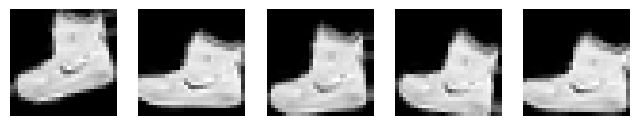

In [ ]:
# Step 4.5 VISUAL PROOF

sample = X_train_aug[0].reshape(1, 28, 28, 1)

plt.figure(figsize=(8,4))

i = 0
for batch in datagen.flow(sample, batch_size=1):
    plt.subplot(1, 5, i+1)
    plt.imshow(batch[0].reshape(28,28), cmap='gray')
    plt.axis('off')

    i += 1
    if i == 5:
        break

plt.show()

### 3. Neural Network Implementation

In [ ]:
# Step 5: Model Architecture

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28, 28)),   # convert image → vector

    Dense(128, activation='relu'),   # hidden layer
    Dense(64, activation='relu'),    # second hidden layer (optional but good)

    Dense(10, activation='softmax')  # output layer (10 classes)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Step 6: Compilation

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Step 7: Training

history = model.fit(
    X_train_norm,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8171 - loss: 0.5166 - val_accuracy: 0.8494 - val_loss: 0.4142
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8610 - loss: 0.3796 - val_accuracy: 0.8625 - val_loss: 0.3777
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8758 - loss: 0.3383 - val_accuracy: 0.8702 - val_loss: 0.3565
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8827 - loss: 0.3177 - val_accuracy: 0.8737 - val_loss: 0.3479
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8894 - loss: 0.2992 - val_accuracy: 0.8786 - val_loss: 0.3380
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8938 - loss: 0.2856 - val_accuracy: 0.8721 - val_loss: 0.3551
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8986 - loss: 0.2705 - val_accuracy: 0.8835 - val_loss: 0.3282
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9026 - loss: 0.2609 - 

### 4. Model Evaluation

In [ ]:
# Step 8: Predictions on Test Set

import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test_norm)

# Convert to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# Step 9: Classification Report (Precision, Recall, F1-score)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.80      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.80      0.80      1000
       Dress       0.84      0.92      0.88      1000
        Coat       0.79      0.84      0.81      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.74      0.68      0.71      1000
     Sneaker       0.90      0.97      0.94      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.98      0.91      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



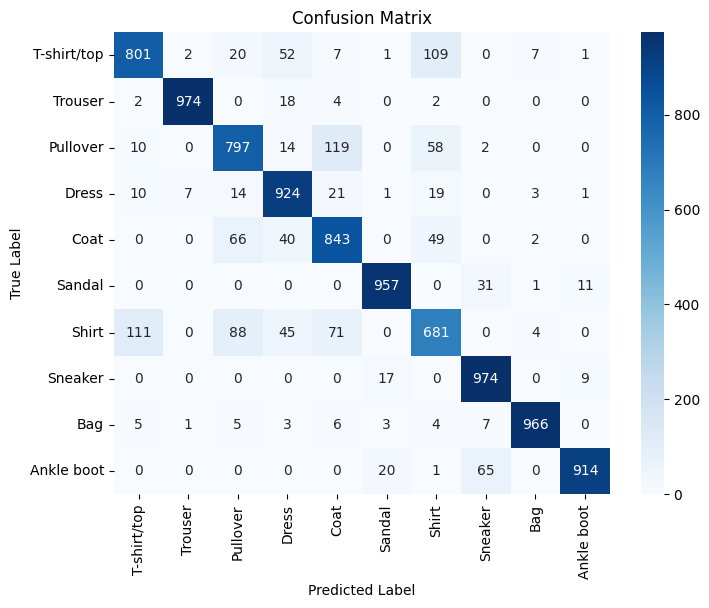

In [ ]:
# Step 10: Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Step 11: Overall Accuracy

test_loss, test_acc = model.evaluate(X_test_norm, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8831 - loss: 0.3757
Test Accuracy: 0.8830999732017517


## Application

This model could be deployed in a fashion retail environment to automatically classify clothing items from images, improving product tagging, inventory management, and visual search systems.

In a real-world setting, the system would need to handle large-scale image inputs and support real-time or near real-time predictions for seamless integration with online platforms or in-store applications. Key operational challenges include ensuring scalability for high traffic, maintaining fast inference speeds, and integrating the model with existing retail databases and backend systems. Additionally, performance may be affected by real-world image variations such as lighting, angles, and background noise.

## Summary

This project uses a feedforward neural network to classify images from the Fashion-MNIST dataset into 10 categories. The dataset consists of 28×28 grayscale images of clothing items, and the model is built using a simple dense neural network architecture.

The methodology includes data normalization, image augmentation, model training using the Adam optimizer, and evaluation using accuracy, classification reports, and a confusion matrix.The results show reasonable classification performance, supported by the confusion matrix and evaluation metrics.

The results show that the model achieves reasonable classification performance, though it is limited by its simple architecture. This model can be applied in fashion retail for automated image tagging and search, but real-world deployment would require handling scalability, inference speed, and image variability challenges.

Future improvements include using convolutional neural networks (CNNs), tuning hyperparameters, and improving generalization for more complex real-world data.